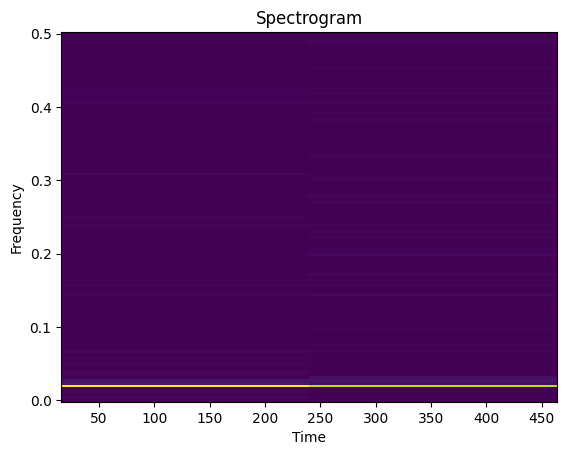

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def generate_signal(human=True):
    t = np.linspace(0, 1, 500)

    if human:
        signal = np.sin(2 * np.pi * 10 * t) + 0.5*np.random.randn(500)
    else:
        signal = 0.5 * np.random.randn(500)

    return signal

# Generate example
signal = generate_signal(True)

# Convert to spectrogram
f, t, Sxx = spectrogram(signal)

plt.pcolormesh(t, f, Sxx)
plt.ylabel('Frequency')
plt.xlabel('Time')
plt.title('Spectrogram')
plt.show()

In [9]:
X = []
y = []

for _ in range(500):
    sig = generate_signal(True)
    _, _, Sxx = spectrogram(sig)
    X.append(Sxx)
    y.append(1)

for _ in range(500):
    sig = generate_signal(False)
    _, _, Sxx = spectrogram(sig)
    X.append(Sxx)
    y.append(0)

X = np.array(X)
y = np.array(y)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np # Ensure numpy is imported for squeeze and newaxis

# Ensure X has the correct 4D shape (batch, height, width, channels)
X = X.squeeze() # Remove any redundant dimensions of size 1
X = X[..., np.newaxis] # Add a channel dimension, if not already present

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X.shape[1:], padding='same'), # Added padding='same'
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'), # Added padding='same'
    MaxPooling2D((2,1)), # Changed from (2,2) to (2,1) to prevent width from becoming 0

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9987 - loss: 0.0487 - val_accuracy: 1.0000 - val_loss: 2.1250e-06
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 1.5647e-06 - val_accuracy: 1.0000 - val_loss: 8.7774e-08
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 3.3120e-07 - val_accuracy: 1.0000 - val_loss: 6.4258e-08
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 1.0000 - loss: 2.7263e-07 - val_accuracy: 1.0000 - val_loss: 6.2898e-08
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 2.4118e-07 - val_accuracy: 1.0000 - val_loss: 6.3069e-08


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


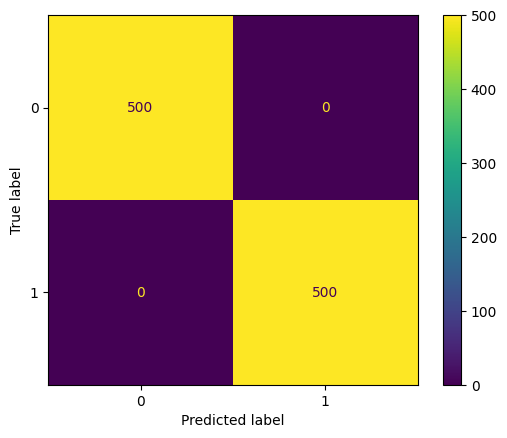

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (model.predict(X) > 0.5).astype("int32")

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [20]:
!pip install streamlit
import streamlit as st

st.title("EchoVision Radar Detection")

if st.button("Detect Human"):
    st.write("Human Detected ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.7 MB/s eta 0:00:00


2026-03-24 06:04:37.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.774 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-24 06:04:38.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.780 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:04:38.803 Thread 'MainThread': mi

In [27]:
%%writefile app.py
import streamlit as st

st.title("EchoVision Radar Detection")

if st.button("Detect Human"):
    st.write("Human Detected ✅")

Overwriting app.py


In [24]:
model.save("echovision_model.h5")

In [25]:
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from scipy.signal import spectrogram

# Load model
model = load_model("echovision_model.h5")

st.title("EchoVision Radar Detection")

# Generate signal (same as training)
def generate_signal(human=True):
    t = np.linspace(0, 1, 500)
    if human:
        return np.sin(2 * np.pi * 10 * t) + 0.5*np.random.randn(500)
    else:
        return 0.5*np.random.randn(500)

def get_spectrogram(signal):
    _, _, Sxx = spectrogram(signal)
    return Sxx[:50, :50]

if st.button("Detect Human"):
    signal = generate_signal(np.random.choice([True, False]))
    spec = get_spectrogram(signal)

    spec = spec[np.newaxis, ..., np.newaxis]

    prediction = model.predict(spec)

    if prediction > 0.5:
        st.success("Human Detected ✅")
    else:
        st.error("No Human Detected ❌")

2026-03-24 06:07:44.578 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.586 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.589 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.591 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 06:07:44.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

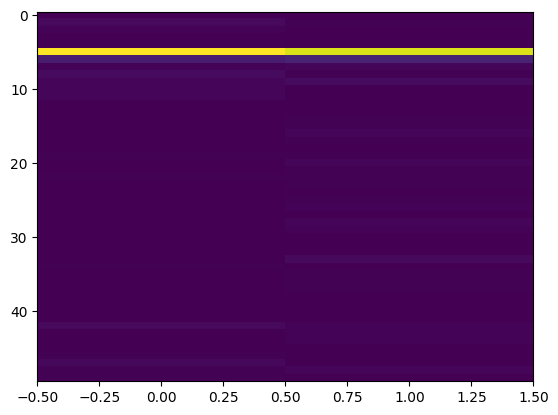

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Generate signal
t = np.linspace(0, 1, 500)
signal = np.sin(2 * np.pi * 10 * t) + 0.5*np.random.randn(500)

# Create spectrogram
_, _, spec = spectrogram(signal)

# Fix size (optional but good)
spec = spec[:50, :50]

# Plot
fig, ax = plt.subplots()
ax.imshow(spec, aspect='auto')
plt.show()